In [9]:
# Generelle moduler og funksjonsbeskrivelser brukt i forelesningen
from numpy import sin, cos, pi, exp, angle, abs, unwrap, log10, e
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from IPython.display import Audio

plt.rcParams["figure.figsize"] = [8.00, 4.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0.0

%matplotlib inline

# Enable importing from modules in top-level directory
from sys import path
if path[0] != '..': path.insert(0, '..')

<img src="figurer/NTNU_logo_vertical.svg" align="left" width="30%">
<br clear="all" />
<br></br>


# Frekvensrespons

* **Emne AIS2102 - Dynamiske System**
* **26. Januar 2026**
* **Underviser: Kai Erik Hoff**

# Z-plan og frekvensrespons

* Substitusjonen $z=e^{j\hat{\omega}}$ i transferfunksjonen $H(z)$ gir systemets frekvensrespons $H(e^{j\hat{\omega}})$.

$$ H(e^{j\hat{\omega}}) = H(z)\bigg|_{z = e^{j\hat{\omega}}}$$

* Frekvensresponsen er oppgitt langs ***enhetssirkelen*** i z-planet.
    * Sirkulær "frekvensakse" medfører at alle aliaser av et digitalt signal er representert av samme punkt i z-planet.
    
<img src="figurer/Fig11_Hz2Hw.png" style="width: 90%" />

## Demo frekvensrespons

Output()

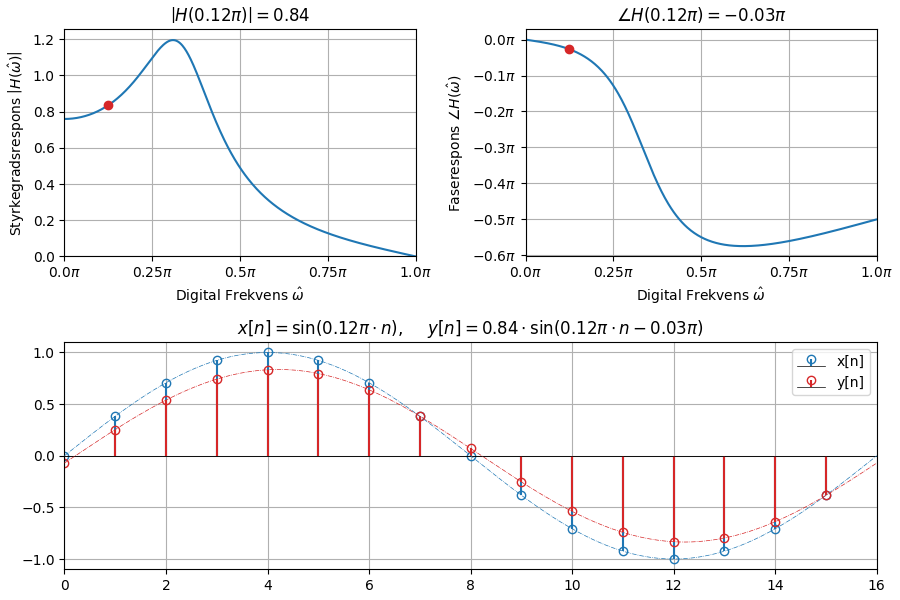

In [12]:
from demos import FreqRespDemo
%matplotlib ipympl
b = np.array([.3, .3])
a = np.array([1, -0.7, 0.49])
FreqRespDemo(b, a, figsize=(9,6));

# Frekvensrespons og sinuspåtrykk

$$\Huge u[k] = \cos (\omega_0 \cdot k)$$

$$\Huge y[k] = |H(\omega_0)| \cdot \cos(\omega_0 \cdot k + \angle H(\omega_0))$$

## Regneeksempel 1:

1. Et filter har transferfunksjonen 
$$H(z) = \frac{1 - z^{-1}+ z^{-2}}{1+0.7\cdot z^{-1}+0.49\cdot z^{-2}}$$
Finn et uttrykk for frekvensresponsen $H(\hat{\omega})$
2. Hva blir $y[k]$ når $u[k]=\sin\left(\frac{\pi}{2}\cdot k\right)$ ?
3. Bruk Python  til å tegne et plot av frekvensresponsen i lineær skala. Verifiser at utregningen i del 2 er korrekt

In [10]:
H = 1j/(0.51 - 0.7j)
abs(H), np.angle(H, deg=True)

(1.154623566040508, np.float64(143.9239884436314))

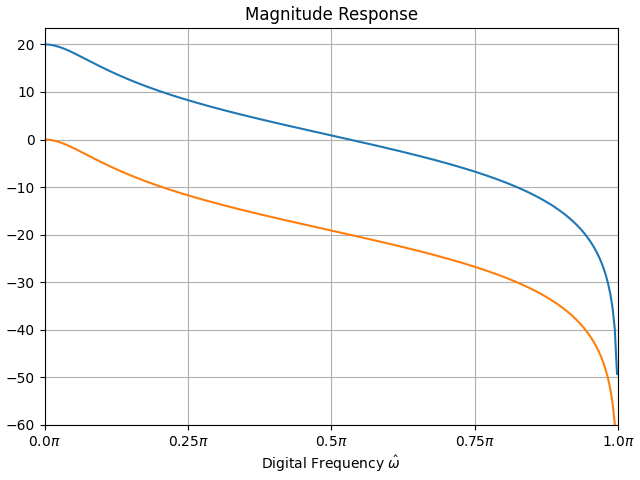

In [4]:
b = np.array([1, 1])
a = np.array([1, -0.8])
plt.close(6); plt.figure(6)
Magnitude_dB(b, a)
Magnitude_dB(0.1*b, a)

# Poler, nullpunkt og frekvensrespons

<img src="figurer/Slide10.PNG" style="width: 70%" align="left"/>

## Illustrasjon
<img src="figurer/Slide11.PNG" style="width: 80%" align="left"/>


## Kodeeksempel: Frihåndsdesign av system

D:\jupyter\AIS2102_Diskretisering\z-transformasjon\..\demos\z_transform.py:49: RuntimeWarning: divide by zero encountered in log10
  ax.plot(x_w, y_w, 20*np.log10(np.abs(Hw)), linewidth=3, color='tab:red')
D:\jupyter\AIS2102_Diskretisering\z-transformasjon\..\demos\z_transform.py:81: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20*np.log10(np.abs(Hw)))
C:\Users\kaier\AppData\Local\Programs\Python\Python312\Lib\site-packages\mpl_toolkits\mplot3d\proj3d.py:150: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0] / w, vecw[1] / w, vecw[2] / w


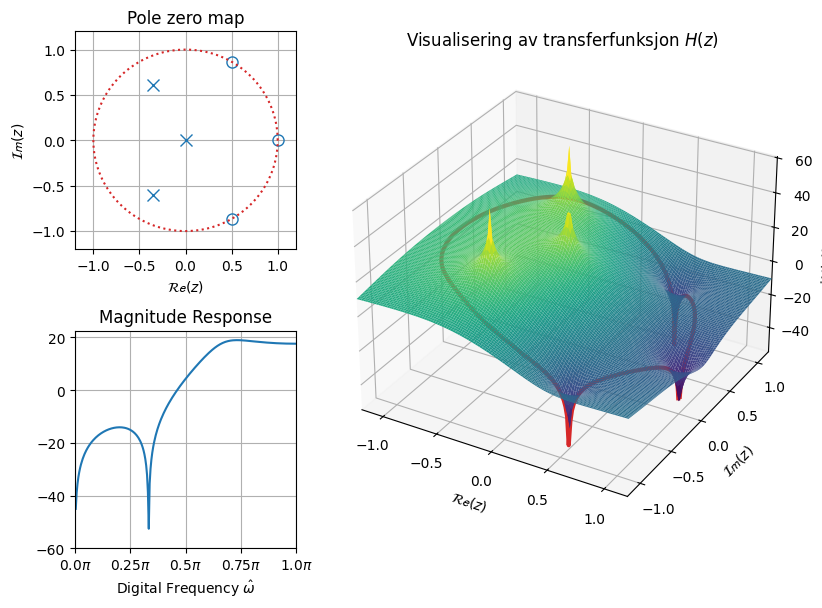

In [11]:
from demos import visualizeTF

zeroes = np.array([exp(1j*pi/3), exp(-1j*pi/3), 1])

poles = np.array([0.7*exp(2j*pi/3), 0.7*exp(-2j*pi/3)])

b, a = sig.zpk2tf(zeroes, poles, 1)
visualizeTF(b, a, fig_num=5)

# Quiz:
<img src="figurer/Slide17.PNG" style="width: 90%" align="left"/>